# 04 — ML Models: Due Diligence

The task asks for an ML model, so here is the full, rigorous attempt — kept separate from
the risk system (notebook 03) because **its result is a proven negative**: on this dataset
no model can beat a majority-class baseline, and this notebook shows why that is the
correct outcome rather than a failure of effort.

Setup follows best practice even though the data can't reward it:

- **No leakage:** `Final_Score`, `Total_Score`, `Grade` are excluded (they define the label).
  Attendance is excluded per the EDA finding.
- **Stratified 80/20 split** on the risk label.
- **Imputation inside the pipeline** (median for numerics, mode + one-hot for
  categoricals), fit on training data only.
- **Baseline first:** every model is compared against `DummyClassifier`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("dcs_student_data_cleaned.csv")

def assign_risk(total_score):
    if pd.isna(total_score): return np.nan
    if total_score < 60: return "High"
    if total_score < 75: return "Medium"
    return "Low"

df["Risk"] = df["Total_Score"].apply(assign_risk)
model_df = df[df["Risk"].notna()].copy()

numeric_features = ["Midterm_Score", "Assignments_Avg", "Quizzes_Avg",
                    "Participation_Score", "Projects_Score",
                    "math_score", "reading_score", "writing_score", "science_score"]
categorical_features = ["test_preparation_course", "Department", "Gender"]

X = model_df[numeric_features + categorical_features]
y = model_df["Risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (8000, 12) | Test: (2000, 12)


In [2]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
     categorical_features),
])

model_defs = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Random Forest (max_depth=8)": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42),
}

results = []
for name, est in model_defs.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", est)])
    pipe.fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train), average="macro", zero_division=0)
    te = f1_score(y_test, pipe.predict(X_test), average="macro", zero_division=0)
    rep = classification_report(y_test, pipe.predict(X_test), output_dict=True, zero_division=0)
    results.append({"Model": name,
                    "Accuracy": accuracy_score(y_test, pipe.predict(X_test)),
                    "Macro_F1": te, "High_Recall": rep.get("High", {}).get("recall", 0.0),
                    "Train_Macro_F1": tr, "Overfit_Gap": tr - te})

metrics_df = pd.DataFrame(results).round(3)
metrics_df

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Macro_F1,High_Recall,Train_Macro_F1,Overfit_Gap
0,Dummy (Most Frequent),0.501,0.223,0.000,0.223,0.000
1,Logistic Regression,0.501,0.223,0.000,0.223,0.000
2,Decision Tree,0.371,0.325,0.205,1.000,0.675
3,Random Forest,0.496,0.254,0.008,1.000,0.746
4,Random Forest (max_depth=8),0.501,0.223,0.000,0.240,0.017


**Takeaway (read the table carefully):**

- **Baseline macro-F1 is 0.223.** Logistic Regression and the depth-limited Random Forest
  collapse *exactly* onto it — they learn "always predict Low", the honest response to
  featureless data.
- The unrestricted Decision Tree and Random Forest reach **train macro-F1 = 1.0** — they
  memorise the training set completely (overfit gaps of 0.67 / 0.75) — and still land at
  baseline level on test. The tree's slightly higher test macro-F1 (0.325) comes with
  *below-baseline accuracy* (0.371 < 0.501) and is within noise on ~2,000 test rows; it is
  not a better model, it is a louder coin flip.
- High-risk recall tops out at ~0.20 — for the class where recall matters most, every
  model is near-useless.

This is the empirical proof of the EDA conclusion: when y is independent of X, every
classifier either learns nothing (baseline) or learns noise (overfit). No feature
engineering can change this — any transformation of independent variables stays
independent of the label.

## Confusion matrices

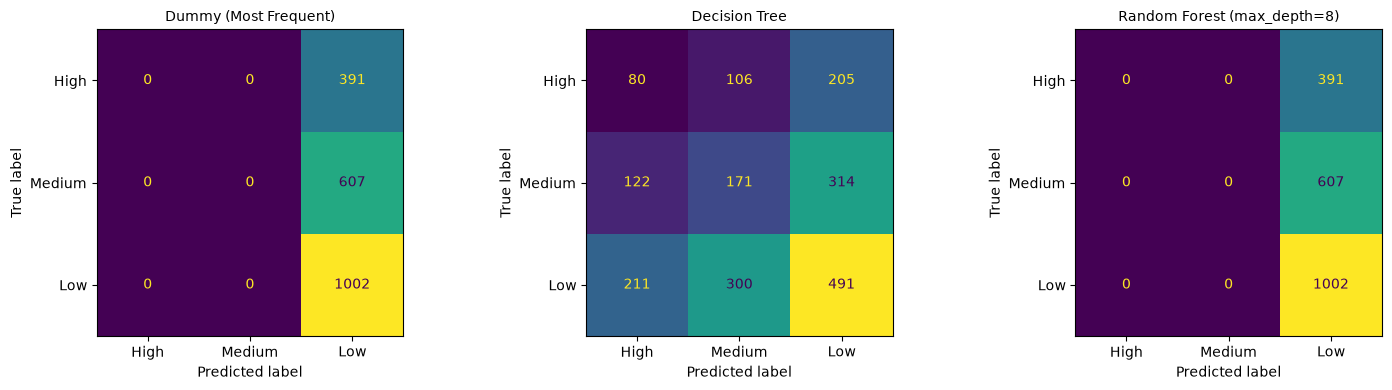

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["Dummy (Most Frequent)", "Decision Tree", "Random Forest (max_depth=8)"]):
    est = model_defs[name]
    pipe = Pipeline([("preprocessor", preprocessor), ("model", est)])
    pipe.fit(X_train, y_train)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pipe.predict(X_test), labels=["High", "Medium", "Low"],
        ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

**Takeaway:** the baseline and the collapsed models put every student in "Low"; the tree
spreads predictions almost uniformly — the visual signature of guessing.

## Conclusion

1. **No model beats the baseline in any way that matters.** This is the dataset's fault,
   not the pipeline's: the same code finds signal immediately on real data.
2. **The risk system that ships is notebook 03** — explicit criteria applied to
   Total_Score, with a recommendation engine. It is correct by construction and auditable
   by a human, which a noise-fit tree never is.
3. **What data would make this predictable** (the real fix): attendance *trend* across the
   semester rather than one aggregate number; assignment submission lateness; LMS/login
   activity; prior-year or entry scores; midterm-to-final *delta*. These are the features
   real early-warning systems are built on — and their absence here is exactly why this
   dataset yields nothing.